**Set environment**

In [2]:
%run ../run_config_project.py
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data


You are working with      IGVF BlueSTARR
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references



In [25]:
import numpy     as np
import pandas    as pd
import itertools as it
import pickle
import os
import time
import argparse

import matplotlib.pyplot as plt
from Bio import SeqIO

from motifdelta.encode import one_hot_encode
from motifdelta.rc     import reverse_complement_matrix

## Functions

In [4]:
def pad_motifs_to_max(dct_lods, alphabet="ACGT"):
    """
    dct_lods: dict {motif_name: arr_lod (W, B)}
    returns:
      arr_kern: (M, W_max, B) float32
    """
    names  = list(dct_lods.keys())
    widths = [dct_lods[n].shape[0] for n in names]
    W_max  = max(widths)
    M      = len(names)
    B      = dct_lods[names[0]].shape[1]
    
    arr_kern = np.zeros((M, W_max, B), dtype=np.float32)
    for i, n in enumerate(names):
        W = dct_lods[n].shape[0]
        arr_kern[i, :W, :] = dct_lods[n]
    return arr_kern

def batch_sliding_window(arr_seq_NxLxB, W):
    """
    Create batched sliding windows over sequences.

    Parameters
    ----------
    arr_seq_NxLxB : np.ndarray
        Shape (N, L, B). One-hot encoded sequences.
    W : int
        Motif width (max motif width).

    Returns
    -------
    arr_win : np.ndarray
        Shape (N, P, W, B), where P = L - W + 1.
    """
    ### get dimentions
    N, L, B = arr_seq_NxLxB.shape
    P = L - W + 1
    
    if W > L:
        raise ValueError(f"Motif width W={W} > sequence length L={L}")

    # Allocate output: (N, P, W, B)
    arr_out = np.empty((N, P, W, B), dtype=arr_seq_NxLxB.dtype)

    # Compute sliding windows per sequence (fast + safe)
    for i in range(N):
        arr_out[i] = np.lib.stride_tricks.sliding_window_view(arr_seq_NxLxB[i], (W, B)).reshape(P, W, B)

    return arr_out

def scan_sequence_batch(arr_seq_NxLxB, arr_motif_fwd_MxWxB, arr_motif_rev_MxWxB):
    """
    Batch motif scanning for forward and reverse strands.

    Parameters
    ----------
    arr_seq_NxLxB : np.ndarray
        One-hot sequences, shape (N, L, B).
    arr_motif_fwd_MxWxB : np.ndarray
        Forward-strand motif LLR kernels, shape (M, W, B).
    arr_motif_rev_MxWxB : np.ndarray
        Reverse-strand motif LLR kernels, shape (M, W, B).

    Returns
    -------
    arr_out : np.ndarray
        Scanning results, shape (N, M, P, 2).
        2 = forward and reverse strands.
    """

    # ----------------------------
    # Dimension checks
    # ----------------------------
    N,  L,  B     = arr_seq_NxLxB.shape
    M,  W,  B_fwd = arr_motif_fwd_MxWxB.shape
    M2, W2, B_rev = arr_motif_rev_MxWxB.shape

    # Confirm motifs match
    assert M == M2,  "Forward and reverse must have same number of motifs"
    assert W == W2,  "Forward and reverse must have same motif width"
    assert B == B_fwd == B_rev, "Alphabet dimension mismatch"

    P = L - W + 1
    if P <= 0:
        raise ValueError(f"Sequence length L={L} must be >= motif width W={W}")

    # ----------------------------
    # Batched sliding windows
    # ----------------------------
    
    ### Batched sliding windows
    ### arr_win: (N, P, W, B)
    arr_win = batch_sliding_window(arr_seq_NxLxB, W)

    ### Forward strand scanning
    ### arr_fwd: (N, M, P)
    arr_fwd = np.einsum(
        "n p w b, m w b -> n m p",
        arr_win,
        arr_motif_fwd_MxWxB,
        optimize=True
    )

    ### Reverse strand scanning
    arr_rev = np.einsum(
        "n p w b, m w b -> n m p",
        arr_win,
        arr_motif_rev_MxWxB,
        optimize=True
    )

    ### Combine forward + reverse
    arr_out = np.stack([arr_fwd, arr_rev], axis=-1).astype(np.float32)
    return arr_out

## Import fasta data

**Check data existence**

In [5]:
%env FD_RES={FD_RES}

env: FD_RES=/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results


In [6]:
%%bash
echo  ${FD_RES}
echo
FDIRY=${FD_RES}/analysis_variant_motif_richard
ls -1 ${FDIRY}/*flankL35R70* | xargs -n 1 basename

/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results

variant_closed_gof_bluestarr_flankL35R70_obs.fa
variant_closed_gof_bluestarr_flankL35R70_ref.fa
variant_closed_gof_bluestarr_flankL35R70_unobs.fa
variant_closed_gof_bluestarr_withseq_flankL35R70.tsv.gz


In [7]:
%%bash
echo  ${FD_RES}
echo
FDIRY=${FD_RES}/analysis_variant_motif_richard/batches_dev
ls -1 ${FDIRY}/*flankL35R70* | xargs -n 1 basename

/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results

variant_closed_gof_bluestarr_flankL35R70_dev10000_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev10000_ref.fa
variant_closed_gof_bluestarr_flankL35R70_dev10000_unobs.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_ref.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_unobs.fa
variant_closed_gof_bluestarr_flankL35R70_dev100_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev100_ref.fa
variant_closed_gof_bluestarr_flankL35R70_dev100_unobs.fa


**Import data**

In [11]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard", "batches_dev")

txt_fpath_ref = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_ref.fa")
txt_fpath_obs = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_obs.fa")
txt_fpath_ubs = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_unobs.fa")

### import data
lst_seq_record_ref = list(SeqIO.parse(txt_fpath_ref, "fasta"))
lst_seq_record_obs = list(SeqIO.parse(txt_fpath_obs, "fasta"))
lst_seq_record_ubs = list(SeqIO.parse(txt_fpath_ubs, "fasta"))

### convert Biopython records to strings
lst_seq_txt_idx = [str(rec.id)          for rec in lst_seq_record_ref]
lst_seq_txt_ref = [str(rec.seq).upper() for rec in lst_seq_record_ref]
lst_seq_txt_obs = [str(rec.seq).upper() for rec in lst_seq_record_obs]
lst_seq_txt_ubs = [str(rec.seq).upper() for rec in lst_seq_record_ubs]

### sanity check: sequence index
assert [rec.id for rec in lst_seq_record_ref] == \
       [rec.id for rec in lst_seq_record_obs] == \
       [rec.id for rec in lst_seq_record_ubs]

### sanity check: sequence length
L = len(lst_seq_txt_ref[0])
assert all(len(seq) == L for seq in lst_seq_txt_ref)
assert all(len(seq) == L for seq in lst_seq_txt_obs)
assert all(len(seq) == L for seq in lst_seq_txt_ubs)

## Import motif

In [18]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard")
txt_fname = "JASPAR2024_CORE_vertebrates_non-redundant.lods.pkl"
txt_fpath = os.path.join(txt_fdiry, txt_fname)

### import data
#obj = np.load(txt_fpath, allow_pickle=True)
with open(txt_fpath, "rb") as f:
    obj = pickle.load(f)
    
print("Object dictionary keys:")
for txt in obj.keys():
    print(txt)
print()

### assign and show
dct_motif_pwms = obj["pwms"]
dct_motif_lods = obj["lods"]
txt_alphabet   = obj["alphabet"]
print(f"Loaded PWMS/LODS for {len(dct_motif_lods)} motifs from {txt_fpath}\n")

print("List of motifs:")
tmp = it.islice(dct_motif_lods.keys(), 10)
for txt in tmp:
    print(txt)

Object dictionary keys:
pwms
lods
bg
names
alphabet

Loaded PWMS/LODS for 879 motifs from /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.lods.pkl

List of motifs:
MA0002.3 Runx1
MA0003.5 TFAP2A
MA0004.1 Arnt
MA0006.2 Ahr::Arnt
MA0007.4 Ar
MA0009.2 TBXT
MA0014.4 PAX5
MA0017.3 NR2F1
MA0018.5 CREB1
MA0019.2 Ddit3::Cebpa


## Set motif kernel

In [15]:
# 1. Build forward (unpadded → right-pad)
arr_motif_lods_fwd = pad_motifs_to_max(dct_motif_lods)
print("Forward kernels shape:", arr_motif_lods_fwd.shape)

# 2. Apply your reverse complement function on the **unpadded motifs**
# (not on the already padded array)
dct_motif_lods_rev = {
    k: reverse_complement_matrix(v) for k, v in dct_motif_lods.items()
}

# 3. Then right-pad the RC motifs in the same way
arr_motif_lods_rev = pad_motifs_to_max(dct_motif_lods_rev)
print("Reverse kernels shape:", arr_motif_lods_rev.shape)

Forward kernels shape: (879, 33, 4)
Reverse kernels shape: (879, 33, 4)


## Run motif scanning

In [21]:
%%time
### one-hot encoding sequences
arr_seq_ref = np.stack([one_hot_encode(txt, txt_alphabet=txt_alphabet) for txt in lst_seq_txt_ref])
arr_seq_obs = np.stack([one_hot_encode(txt, txt_alphabet=txt_alphabet) for txt in lst_seq_txt_obs])
arr_seq_ubs = np.stack([one_hot_encode(txt, txt_alphabet=txt_alphabet) for txt in lst_seq_txt_ubs])

### motif scanning
arr_motif_scan_ref = scan_sequence_batch(arr_seq_ref, arr_motif_lods_fwd, arr_motif_lods_rev)
arr_motif_scan_obs = scan_sequence_batch(arr_seq_obs, arr_motif_lods_fwd, arr_motif_lods_rev)
arr_motif_scan_ubs = scan_sequence_batch(arr_seq_ubs, arr_motif_lods_fwd, arr_motif_lods_rev)

print(arr_motif_scan_ref.shape)
print(arr_motif_scan_obs.shape)
print(arr_motif_scan_ubs.shape)

arr_motif_scan_ref = arr_motif_scan_ref[:,:,:71,:]
arr_motif_scan_obs = arr_motif_scan_obs[:,:,:71,:]
arr_motif_scan_ubs = arr_motif_scan_ubs[:,:,:71,:]

print(arr_motif_scan_ref.shape)
print(arr_motif_scan_obs.shape)
print(arr_motif_scan_ubs.shape)

(100, 879, 74, 2)
(100, 879, 74, 2)
(100, 879, 74, 2)
(100, 879, 71, 2)
(100, 879, 71, 2)
(100, 879, 71, 2)
CPU times: user 509 ms, sys: 2.02 s, total: 2.53 s
Wall time: 232 ms


In [28]:
num_memory = (arr_motif_scan_ref.nbytes * 3) / (1024**3)
print(f"Estimated memory use (ref+obs+unobs): {num_memory:.3f} GB")

Estimated memory use (ref+obs+unobs): 0.139 GB


## Visualize

In [23]:
###
lst_motif_name   = list(dct_motif_lods.keys())
txt_motif_target = "MA0099.4 FOS::JUN"
num_motif_idx    = lst_motif_name.index(txt_motif_target)
num_seq_idx      = 0
txt_seq_idx      = lst_seq_txt_idx[num_seq_idx]
num_strand_idx   = 0 # forward
print("Motif Name: ", txt_motif_target)
print("Motif Index:", num_motif_idx)

###
arr_score_obs   = arr_motif_scan_obs[num_seq_idx, num_motif_idx, :, num_strand_idx]
arr_score_ubs   = arr_motif_scan_ubs[num_seq_idx, num_motif_idx, :, num_strand_idx]
arr_score_delta = arr_score_ubs - arr_score_obs

Motif Name:  MA0099.4 FOS::JUN
Motif Index: 68


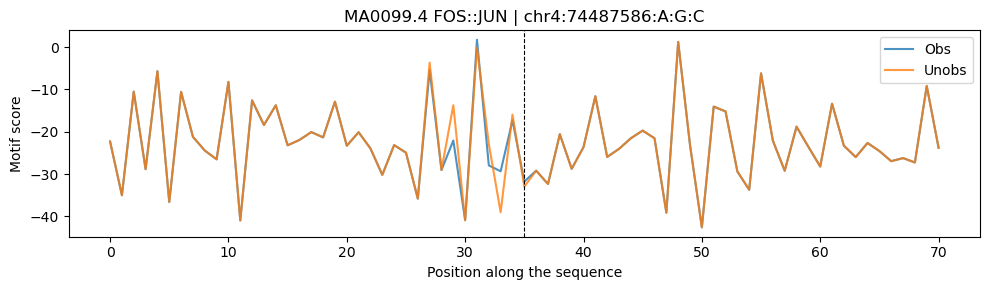

In [26]:
###
plt.figure(figsize=(10,3))
plt.plot(arr_score_obs, label="Obs",   alpha=0.8)
plt.plot(arr_score_ubs, label="Unobs", alpha=0.8)
plt.axvline(35, color="k", linestyle="--", lw=0.8)
plt.legend()
plt.title(f"{txt_motif_target} | {txt_seq_idx}")
plt.xlabel("Position along the sequence")
plt.ylabel("Motif score")
plt.tight_layout()
plt.show()

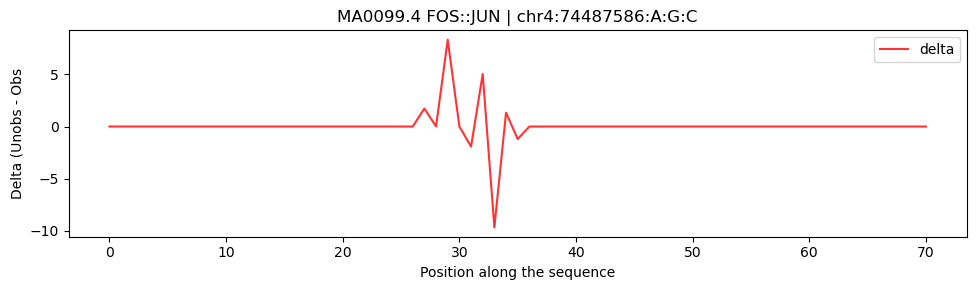

In [27]:
# Plot
plt.figure(figsize=(10,3))
plt.plot(arr_score_delta, label="delta", alpha=0.8, c = "red")
plt.legend()
plt.title(f"{txt_motif_target} | {txt_seq_idx}")
plt.xlabel("Position along the sequence")
plt.ylabel("Delta (Unobs - Obs")
plt.tight_layout()
plt.show()